In [1]:
import xarray as xr
import numpy as np

In [2]:
from xmitgcm.llcreader import faces_dataset_to_latlon

In [4]:
import matplotlib.pyplot as plt
import matplotlib as mpl

import cartopy
import cartopy.feature as cf

from cartopy import crs as ccrs

In [4]:
def open_llc4320_velocity_data(chunks='auto'):
    
    ds_SSU = xr.open_dataset(
        "gs://pangeo-ecco-llc4320/ssu", 
        engine="zarr", 
        storage_options={'requester_pays': True}, 
        chunks=chunks, 
        inline_array=True,
        consolidated=True, 
    )
    
    ds_SSV = xr.open_dataset(
        "gs://pangeo-ecco-llc4320/ssv", 
        engine="zarr", 
        storage_options={'requester_pays': True}, 
        chunks=chunks, 
        inline_array=True,
        consolidated=True, 
    )
    
    # Open grid data
    ds_grid = xr.open_dataset(
        "gs://pangeo-ecco-llc4320/grid", 
        engine="zarr", 
        storage_options={'requester_pays': True}, 
        chunks=chunks, 
        inline_array=True,
        consolidated=True, 
    )
    
    coords_to_keep = ['XC', 'YC', 'dxC', 'dyC', 'dxG', 'dyG', 'rAz', 'rA', 'Depth']
    ds_grid = ds_grid.reset_coords()[coords_to_keep]
        
    ds = xr.merge([ds_SSU, ds_SSV, ds_grid])
    return ds, ds_grid

In [5]:
ds, ds_grid = open_llc4320_velocity_data(chunks={})

In [6]:
latlon_grid = faces_dataset_to_latlon(ds_grid).set_coords(['XC', 'YC', 'dxC', 'dyC', 'dxG', 'dyG'])

In [7]:
depth = latlon_grid['Depth']
depth.name = None  # needed to avoid confusing hvplot when it calls .to_dataset()

In [8]:
XC1 = depth.XC
XC2 = XC1.copy()
XC2[:,2000:] = XC1[:,2000:].where(XC1[:,2000:]>0,XC1[:,2000:]+360)


In [9]:
target_url ='gs://leap-persistent/cspencerjones/hero-calc/masked_hist_renorm_3hr.zarr'
hist_ds = xr.open_dataset(target_url, engine="zarr", chunks={})

In [10]:
from xarray.indexes import PandasIndex

# have to add the index ourselves manually for some reason
hist_ds = hist_ds.set_xindex('region_num', PandasIndex)

In [11]:
XC2.coarsen(i=10,j=10).mean()['XC']

<xarray.DataArray 'XC' (j: 1296, i: 1728)> Size: 9MB
dask.array<mean_agg-aggregate, shape=(1296, 1728), dtype=float32, chunksize=(432, 432), chunktype=numpy.ndarray>
Coordinates:
  * j        (j) float64 10kB 4.5 14.5 24.5 ... 1.293e+04 1.294e+04 1.295e+04
  * i        (i) float64 14kB 4.5 14.5 24.5 ... 1.725e+04 1.726e+04 1.727e+04
    XC       (j, i) float32 9MB dask.array<chunksize=(432, 432), meta=np.ndarray>
    YC       (j, i) float32 9MB dask.array<chunksize=(432, 432), meta=np.ndarray>
Attributes:
    coordinate:     YC XC
    long_name:      longitude
    standard_name:  longitude
    units:          degrees_east

In [22]:
coarsened_depth = (depth.coarsen(i=10,j=10).mean().rename('depth_coarsened').to_dataset()).drop_vars('XC').merge(XC2.coarsen(i=10,j=10).mean()['XC'].rename('lon'))

In [23]:
max_vert = abs(hist_ds.vertices_longitude.diff('vertices')).max('vertices')
hist_ds['lon'] = hist_ds['vertices_longitude'].where((max_vert<100) | (hist_ds.vertices_longitude>-170),hist_ds.vertices_longitude.where((max_vert>100) & (hist_ds.vertices_longitude<-170))+360)
verts = np.stack((hist_ds.lon.values, hist_ds.vertices_latitude.values),2)
verts = np.swapaxes(verts, 0, 1)
verts_da = xr.DataArray(
    verts,
    dims=["region", "vertex", "coord"],
    coords={
        "region": hist_ds["region"],          # align with existing region coord
        "coord": ["x", "y"],             # optional: label the 2 coordinate axes
    },
    name="verts",
)
coarsened_depth = xr.merge([coarsened_depth, verts_da])
coarsened_depth = xr.merge([coarsened_depth, hist_ds.j_region_coarse.rename('j_coarse')])

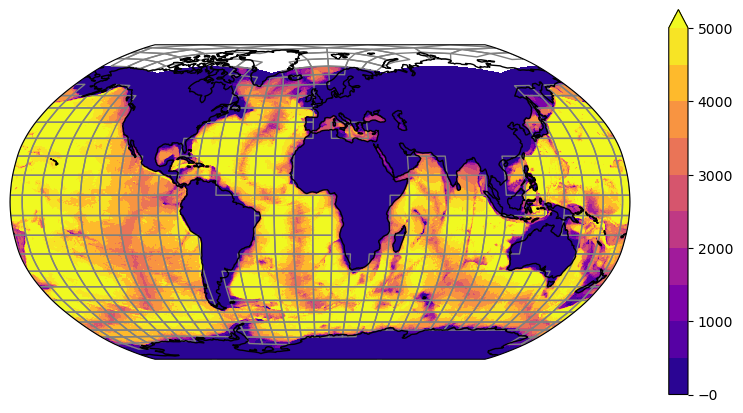

In [5]:
fig = plt.figure(figsize=(10, 5))
plt.clf()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())

ax.set_global()

ax.coastlines()


from matplotlib.collections import PolyCollection

cs = ax.contourf(coarsened_depth.lon.values, coarsened_depth.YC.values, coarsened_depth['depth_coarsened'].values,
                transform=ccrs.PlateCarree(),levels=np.arange(-0.5,5000,500),vmax=5000,cmap='plasma',extend='max')#,levels=np.arange(0,5000,100)
plt.colorbar(cs,extend='max')

# Make the collection and add it to the plot.
coll = PolyCollection(coarsened_depth.verts, array=coarsened_depth.j_region_coarse, edgecolors='grey',facecolors='None', transform=ccrs.PlateCarree())
ax.add_collection(coll)
ax.autoscale_view

fig.savefig('depth_grid.png')